In [3]:
import numpy as np
import pandas as pd

In [4]:
embeddings_dir = "/home/earkfeld/Projects/MitoSpace4D/runs/20260108_kinetics_morphology_resnet_embeddings_all"
# embeddings_dir = "/home/earkfeld/Projects/MitoSpace4D/runs/20260109_kinetics_morphology_resnet_embeddings_all_tscrambled"

embeddings = np.load(f"{embeddings_dir}/embeddings_raw.npy")
img_paths = pd.read_csv(f"{embeddings_dir}/image_paths.csv", header=None)[0].tolist()
labels = np.load(f"{embeddings_dir}/labels.npy")
label_names = np.load(f"{embeddings_dir}/label_names.npy", allow_pickle=True)
metadata = pd.read_csv("/experiments/dhruv_4D_ResnetBiLSTM_phate/kinetics_metadata/phate_kinetics_metadata.csv")

In [5]:
# metadata = metadata[metadata['path'].str.contains("-0.npy")]
metadata['label_name'] = ''
metadata['label_id'] = -1
metadata['embedding'] = None

In [6]:
metadata.head()

,sample id,region id,cell id,movie id,global_start_frame,path,label_name,label_id,embedding
0,20250722-2,0,0,0,0,20250722-2/000000-0.npy,,-1,None
1,20250722-2,0,0,1,20,20250722-2/000000-1.npy,,-1,None
2,20250722-2,0,0,2,40,20250722-2/000000-2.npy,,-1,None
3,20250722-2,0,1,0,0,20250722-2/000001-0.npy,,-1,None
4,20250722-2,0,1,1,20,20250722-2/000001-1.npy,,-1,None


In [7]:
for i, row in metadata.iterrows():
    base_path = row['path']
    matching_indices = [j for j, path in enumerate(img_paths) if base_path in path]
    if matching_indices:
        idx = matching_indices[0]
        metadata.at[i, 'label_name'] = label_names[labels[idx]]
        metadata.at[i, 'label_id'] = labels[idx]
        metadata.at[i, 'embedding'] = embeddings[idx]

In [8]:
len(metadata)

34272

In [25]:
# Average per movie id per region per condition and stack regions for per-condition trajectories
phate_data = []

for lbl in np.unique(labels):
    df_condition = metadata[metadata['label_id'] == lbl].reset_index(drop=True)
    label_name = df_condition.at[0, 'label_name']
    # regions = df_condition['region id'].unique()
    regions = [0]
    for region in regions:
        df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)

        movie_ids = df_region['movie id'].unique()
        # movie_ids = [0]
        for movie_id in movie_ids:
            df_movie = df_region[df_region['movie id'] == movie_id].reset_index(drop=True)
            embeddings = np.mean(np.stack(df_movie['embedding'].to_list()), axis=0)

            t_start = df_movie.at[0, 'global_start_frame']
            for i in range(len(embeddings)):
                t = t_start + i
                phate_data.append({"drug": label_name, "time": float(t), "embedding": embeddings[i]})

df_phate = pd.DataFrame(phate_data)

In [23]:
df_movie.head()

,sample id,region id,cell id,movie id,global_start_frame,path,label_name,label_id,embedding
0,20250813-1,7,319,0,420,20250813-1/000319-0.npy,paraquat,25,"[[-0.011749489, -0.014093505, 0.00792917, 0.04..."
1,20250813-1,7,320,0,420,20250813-1/000320-0.npy,paraquat,25,"[[-0.010634406, -0.014452757, 0.0072899475, 0...."
2,20250813-1,7,321,0,420,20250813-1/000321-0.npy,paraquat,25,"[[-0.010842139, -0.016947297, 0.0100797275, 0...."
3,20250813-1,7,322,0,420,20250813-1/000322-0.npy,paraquat,25,"[[-0.010411938, -0.014088115, 0.006342862, 0.0..."
4,20250813-1,7,323,0,420,20250813-1/000323-0.npy,paraquat,25,"[[-0.01125189, -0.015881265, 0.0128270015, 0.0..."


In [26]:
# Save to parquet
df_phate.to_parquet("kinetics-20frames_4DMS-2024v2_phate_mean-pooled_region-0-only.parquet", engine='pyarrow', index=False)

In [28]:
df_phate.head()

,drug,time,embedding
0,control,0.0,"[-0.011691087, -0.018526882, 0.008311111, 0.03..."
1,control,1.0,"[-0.01721712, -0.030181957, 0.016143741, 0.027..."
2,control,2.0,"[-0.015925312, -0.038486015, 0.026254626, 0.01..."
3,control,3.0,"[-0.012096334, -0.042236127, 0.03153271, 0.014..."
4,control,4.0,"[-0.007672328, -0.04213711, 0.032053597, 0.015..."


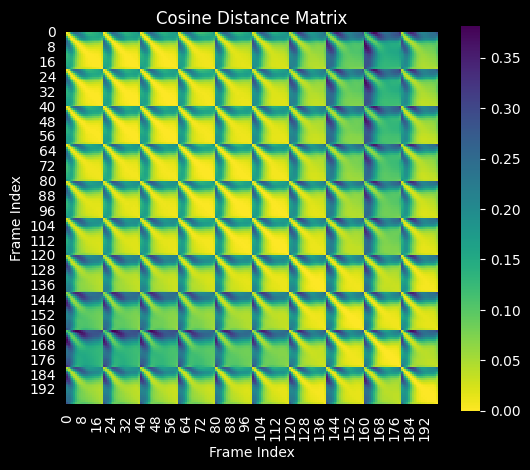

In [35]:
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
embeddings = np.stack(df_phate['embedding'][:200])


dists = cdist(embeddings, embeddings, metric='cosine')

# 3. Plot
plt.figure(figsize=(6, 5))
sns.heatmap(dists, cmap='viridis_r', square=True)
plt.title("Cosine Distance Matrix")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()